Dataset: kaggle.com/datasets/yasserh/housing-prices-dataset    1. Basic EDA & Feature Engineering

1. Load Housing.csv. Print .shape, .dtypes, .isnull().sum(), and .describe().
2. Plot a histogram of price. Is it skewed?
3. Compute .corr() on numeric columns. Which feature correlates most with price?
4. Plot a boxplot of price grouped by stories.



In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

# **1 solve**

In [ ]:
df=pd.read_csv('Housing.csv')
df.sample(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
322,4025000,3460,3,2,1,yes,no,yes,no,yes,1,no,furnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
458,3115000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished
299,4200000,7000,3,1,1,yes,no,no,no,no,3,no,furnished
427,3332000,2145,3,1,2,yes,no,yes,no,no,0,yes,furnished
321,4025000,3630,3,2,2,yes,no,no,yes,no,2,no,semi-furnished
277,4305000,10360,2,1,1,yes,no,no,no,no,1,yes,semi-furnished
107,6125000,6420,3,1,3,yes,no,yes,no,no,0,yes,unfurnished
531,2233000,5300,3,1,1,no,no,no,no,yes,0,yes,unfurnished
474,2975000,4352,4,1,2,no,no,no,no,no,1,no,unfurnished


In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(545, 13)
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000 

# **2 solve**

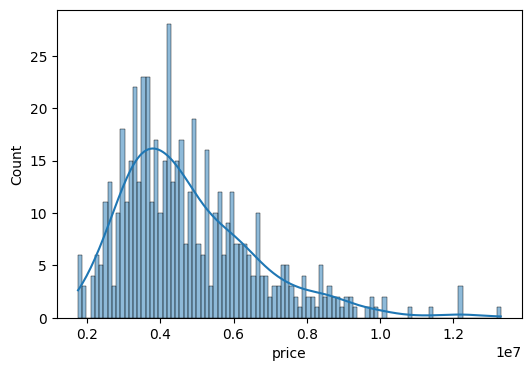

In [ ]:
plt.figure(figsize = (6,4) )
sns.histplot(
    df['price'],
    bins = 100,
    kde = True
)

plt.show()

# right skewed

# **3 solve**

In [ ]:
df.select_dtypes(include=np.number).corr()
# akne area er sathe corelation beshi price er


,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


# **4 solve**

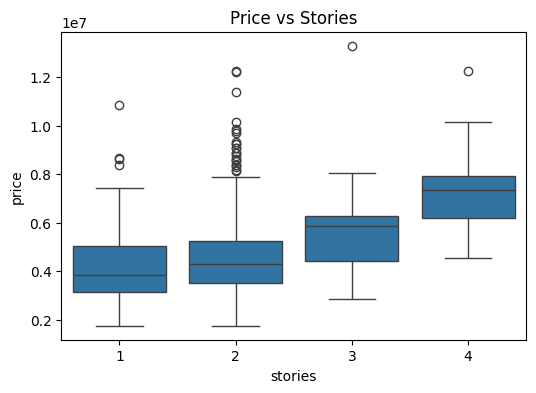

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['stories'], y=df['price'])
plt.title("Price vs Stories")
plt.show()

# **2. Feature Engineering via Pipeline & ColumnTransformer**

1. Split data: X = all features, y = price. Use train_test_split.
2. List your numeric columns in a variable called numeric_features.
3. Build a numeric_pipeline: steps = [SimpleImputer(median), StandardScaler()].
4. Build a column_pipeline
5. Wrap it in ColumnTransformer(transformers=[('num', numeric_pipeline, numeric_features)]).
6. Call preprocessor.fit_transform(X_train) and .transform(X_test). Print the output shape.




# **1 solve**

In [ ]:
x=df.drop('price',axis=1)
y=df['price']

x_train,x_test,y_train,y_test=train_test_split(
   x,y,test_size=0.2,random_state=42)


# **2 solve**

In [ ]:
numeric_features=x.select_dtypes(include=np.number).columns
numeric_features


Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

# **3 solve**

In [ ]:
num_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
num_transformer

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

# **4 solve**

In [ ]:
prepocessor=ColumnTransformer(
    transformers=[
    ('num',num_transformer,numeric_features)

])
prepocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))])

# **6 solve**

In [ ]:
prepocessor.fit_transform(x_train)
prepocessor.transform(x_test)

print(prepocessor.fit_transform(x_train).shape)
print(prepocessor.transform(x_test).shape)


(436, 5)
(109, 5)


# **3. Train LinearRegression & SGDRegressor (using Pipeline)**

1. Build lr_pipeline = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())]).
2. Fit lr_pipeline on X_train, y_train. Print .coef_ and .intercept_.
3. Build sgd_pipeline the same way but use SGDRegressor(random_state=42).
4. Fit sgd_pipeline on X_train, y_train. Print .coef_ and .intercept_.
5. Generate predictions for both models on X_train and X_test.


# **1 solve**

In [ ]:
lr_pipeline =Pipeline(steps=
 [
    ('prepocessor',prepocessor),
    ('model',LinearRegression())
])
lr_pipeline

Pipeline(steps=[('prepocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))])),
                ('model', LinearRegression())])

# **2 solve**

In [ ]:
lr_pipeline.fit(x_train,y_train)

print(lr_pipeline['model'].coef_) # 5 ta ber korse weight dekho train col er soman

print(lr_pipeline['model'].intercept_)


[680058.42414123 112973.18562909 565408.61793601 424354.81176353
 288348.7726677 ]
4706527.385321101


# **3 solve**

In [ ]:

ETA = 0.00001
MAX_ITER = 3000
ALPHA = 0.0001

sgd_pipeline=Pipeline(steps=[

    ('prepocessor',prepocessor),

    ('model',SGDRegressor(
        random_state=42,
        eta0=ETA,
        max_iter=MAX_ITER,
        alpha=ALPHA))

    ])

sgd_pipeline







Pipeline(steps=[('prepocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object'))])),
                ('model',
                 SGDRegressor(eta0=1e-05, max_iter=3000, random_state=42))])

## **4 solve**

In [ ]:
sgd_pipeline.fit(x_train,y_train)

print(sgd_pipeline['model'].coef_)

print(sgd_pipeline['model'].intercept_)

[332006.1482651  188314.02808467 312158.96129278 233510.86590589
 215499.3001817 ]
[1896300.00062892]


# **5 solve**

In [ ]:
lr_train_pred = lr_pipeline.predict(x_train)
lr_test_pred = lr_pipeline.predict(x_test)

sgd_train_pred = sgd_pipeline.predict(x_train)
sgd_test_pred = sgd_pipeline.predict(x_test)

print(lr_train_pred)
print(lr_test_pred)
print(sgd_train_pred)
print(sgd_test_pred)

[ 7048468.97357092  6609128.69348733  3889283.61945779  3487815.92311087
  3839924.25305077  4229096.6177212   3870810.94865954  3754381.07416122
  3168769.32541906  4045951.48070795  3645338.07071556  4413601.21630566
  5361623.58856861  3784328.200955    3457027.28535552  5364495.98552683
  2927853.0996707   5160545.73665557  4479600.687055    8428174.7917489
  6627660.71085259  3608274.03598504  4782882.1020396   5951477.2594548
  7210624.12551693  3809037.55744201  3158057.03980941  3422040.22941092
  5317167.02673169  3777335.28676513  3768884.85315062  2602405.38580775
  3654604.07939819  4773698.30859817  4176954.38149013  4874808.82903897
  3249172.79185527  6187991.56980421  5818347.07066178  6704018.72629249
  7342129.3268503   5572848.14979704  4522520.22600445  3571210.00125453
  4494820.25780998  4094191.00520537  7000265.44858155  6713963.18546251
  3047384.61167662  7534385.94279125  4584995.29182445  3694388.57016649
  7241808.28269704  6136797.43310739  5670090.9317397

# **4. Evaluation Metrics — RMSE, MAE, R²**

1. Compute RMSE, MAE, R² for LinearRegression on both train and test sets.
2. Compute the same metrics for SGDRegressor.
3. Print all results in one table using a pandas DataFrame.



In [ ]:
def evaluate(modal,name):
  y_pred_train=modal.predict(x_train)
  y_pred_test=modal.predict(x_test)



  print(f"\n{name}")
  print("-"*40)
  print("Train R2 :", round(r2_score(y_train, y_pred_train),4))
  print("Test R2  :", round(r2_score(y_test, y_pred_test),4))
  print("RMSE     :", round(np.sqrt(mean_squared_error(y_test,  y_pred_test)),4))
  print("MAE      :", round(mean_absolute_error(y_test, y_pred_test),4))


  # y_train = Train set এর আসল (actual) price
  # y_pred_train = Model train set এর জন্য যা predict করেছে
  # y_test = Test set এর আসল price
  # y_pred_test = Model test set এর জন্য যা predict করেছে

  return (
    r2_score(y_test, y_pred_test),
    np.sqrt(mean_squared_error(y_test, y_pred_test)),
    mean_absolute_error(y_test, y_pred_test)
)



## **basic note:** why predict use x _train X test
এটাই ML-এর সবচেয়ে গুরুত্বপূর্ণ ধারণাগুলোর একটা।

তুমি model train করেছো:

```python
model.fit(X_train, y_train)
```

এখানে model শিখেছে:

```text
X  --->  y
```

অর্থাৎ feature (X) থেকে target (y) কিভাবে বের করতে হয়।

---

ধরো housing dataset:

| area | bedrooms | bathrooms | price   |
| ---- | -------- | --------- | ------- |
| 1000 | 2        | 1         | 5000000 |
| 1200 | 3        | 2         | 6500000 |

এখানে:

```python
X_train =
[
 [1000,2,1],
 [1200,3,2]
]

y_train =
[
 5000000,
 6500000
]
```

---

Train হওয়ার পর model একটা relation শিখে:

```text
price = area × w1 + bedrooms × w2 + bathrooms × w3 + b
```

---

এখন তুমি যখন লিখো:

```python
y_pred_train = model.predict(X_train)
```

তখন model-কে বলছো:

> "তুমি যেটা শিখেছো, সেই একই X_train-এর জন্য price predict করে দেখাও।"

---

ধরো model predict করল:

```python
y_pred_train =
[
 5100000,
 6400000
]
```

এখন compare করা হবে:

| Actual  | Predicted |
| ------- | --------- |
| 5000000 | 5100000   |
| 6500000 | 6400000   |

এরপর Train R² বের হয়।

---

### কিন্তু train করার সময় তো y_train দিয়েছিলাম, আবার predict কেন?

কারণ training-এর সময় model **শিখে**।

```python
model.fit(X_train, y_train)
```

Prediction দেয় না।

---

Prediction পাওয়ার জন্য আলাদা করে:

```python
model.predict(X_train)
```

চালাতে হয়।

---

বাস্তবে flow:

```text
fit()
│
├── X_train দেখে
├── y_train দেখে
└── weights শিখে


predict()
│
├── শুধু X লাগে
└── model y বের করে
```

---

খেয়াল করো:

```python
predict()
```

এর মধ্যে কখনো `y` দেওয়া হয় না।

কারণ model-এর কাজই হলো **X দেখে y অনুমান করা**।

তাই:

```python
model.predict(X_train)
```

মানে:

> "যে data দিয়ে তোমাকে শিখিয়েছি, ওই data-র answer তুমি নিজে predict করে দেখাও।"

আর

```python
model.predict(X_test)
```

মানে:

> "নতুন data-র answer predict করে দেখাও।"

এই দুইটার comparison থেকেই Train R² আর Test R² পাওয়া যায়।


## **important note**

r2_score() একটা scikit-learn-এর built-in function। এটা fixed name।

তুমি import করো:

from sklearn.metrics import r2_score

তারপর ব্যবহার করো:

r2_score(y_true, y_pred)

এখানে:

y_true = আসল মান (actual)
y_pred = model-এর prediction

তোমার ক্ষেত্রে:

r2_score(y_train, y_pred_train)

মানে:

Actual Train Values
        vs
Predicted Train Values

আর

r2_score(y_test, y_pred_test)

মানে:

Actual Test Values
        vs
Predicted Test Values

R2=1−∑(yi​−yˉ​)2∑(yi​−y^​i​)2​


ভেতরে r2_score() R² formula হিসাব করে:


তুমি চাইলে নিজের variable name দিতে পারো:

score = r2_score(y_test, y_pred_test)

print(score)

কিন্তু function-এর নাম r2_score-ই থাকবে (যদি alias না দাও)।

যেমন:

from sklearn.metrics import r2_score as r2

r2(y_test, y_pred_test)

এখানে r2 নামটা তুমি নিজে দিয়েছো।

একইভাবে:

mean_squared_error()
mean_absolute_error()
accuracy_score()

In [ ]:
lr_r2 ,lr_rmse,lr_mase = evaluate(
    lr_pipeline,
    "Linear Regression"
)


Linear Regression
----------------------------------------
Train R2 : 0.5622
Test R2  : 0.5464
RMSE     : 1514173.552
MAE      : 1127483.3523


In [ ]:
lr_r2 ,lr_rmse,lr_mase = evaluate(
    lr_pipeline,
    "SGDRegressor"
)


SGDRegressor
----------------------------------------
Train R2 : 0.5622
Test R2  : 0.5464
RMSE     : 1514173.552
MAE      : 1127483.3523


## **5. Compare Both Models**

1. Which model has lower Test RMSE — LinearRegression or SGDRegressor?
2. Is Train R² much higher than Test R²?


If yes, the model may be overfitting. Learn about Overfitting and Underfitting

## **solve**

LinearRegression RMSE = 1514173
SGDRegressor RMSE = 1530000

যার RMSE কম, সেই model better।

LinearRegression has the lower Test RMSE, so it performs slightly better on the test data.

Train R² = 0.5622
Test R²  = 0.5464

0.5622 - 0.5464
= 0.0158

No. Train R² is only slightly higher than Test R². The difference is very small, so there is no strong sign of overfitting.


# **Overfitting vs Underfitting**

Overfitting occurs when a model performs very well on training data but poorly on test data. Underfitting occurs when a model performs poorly on both training and test data because it fails to learn the underlying pattern. In this case, the model appears reasonably balanced and does not show strong overfitting.